# Training Analysis and Visualization Dashboard

### TLDR
This notebook compiles validation visualizations for model performance, currently focusing on the Resnet model trained on the Galaxy dataset.

### Objective
Conduct a comprehensive analysis of training dynamics and mask evolution for the Resnet architecture.

### Description
* **Data Selection**: Loads data for a specifically chosen epoch alongside complete training metrics and logs.
* **Trend Analysis**: Generates evolution curves for losses, accuracy, and regularization terms.
* **Performance Verification**: Verifies key performance indicators (accuracy, F1, recall, precision) for the selected epoch.
* **Error Analysis**: Renders the confusion matrix.
* **Feature Selection**: Visualizes the feature selection mask's evolution through both static views and animations.

### Results
* **Mask Evolution**: The mask demonstrates expected evolutionary behavior.
* **Classification Performance**: The selected epoch (150) exhibits strong classification performance despite significant pixel deselection.
* **Pending**: (TODO: quantify exact mask loss).


In [1]:
# Importing functions and methods.
import sys
import os

current_dir = os.getcwd() 
utils_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'utils'))
models_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'models'))
notebook_utils = os.path.abspath(os.path.join(current_dir, '..'))

if utils_path not in sys.path: sys.path.append(utils_path)
if models_path not in sys.path: sys.path.append(models_path)
if notebook_utils not in sys.path: sys.path.append(notebook_utils)

print(f"Adicionado ao PATH: {utils_path}")
print(f"Adicionado ao PATH: {models_path}")
print(f"Adicionado ao PATH: {notebook_utils}")

# 2. Third-party Library Imports (Data, Math, ML)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms

# 3. Visualization Imports
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
import pandas as pd

# 4. Local/Project Imports (Custom Modules)
from StaticMaskTraining import StaticMaskTraining
import NotebookUtils as nu
import ModelTester as mt
import DatasetsDict as dd

Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/utils
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/models
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/notebooks


/home/andre-marques/anaconda3/envs/PowerRanger-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# SETTING GLOBAL VARIABLES
var_root_dir = "../../checkpoints/"
var_global_checkpoint_masked = "galaxy10_resnet20_masked"
var_global_checkpoint_unmasked = "galaxy10_resnet20_unmasked"
var_global_epoch = 15

# Setting the class helper
utils = nu.NotebookUtils()

In [5]:
def rebuild_training_log(training_id, root_dir="../../checkpoints/"):
    data_list = []
    i = 1
    eps = 1e-9 

    print(f"🔄 Reconstruindo log para: {training_id}")

    while True:
        path = os.path.abspath(os.path.join(root_dir, training_id, f'checkpoint_epoch_{i}.pt'))
        
        if not os.path.exists(path):
            break
            
        try:
            # Carregando com weights_only=False por causa da CM (numpy)
            ckpt = torch.load(path, map_location='cpu', weights_only=False)
            
            cm = np.array(ckpt['cm'])
            
            # --- CÁLCULOS ---
            tp = np.diag(cm)
            fp = np.sum(cm, axis=0) - tp
            fn = np.sum(cm, axis=1) - tp
            
            # Precisão e Recall por classe
            p_class = tp / (tp + fp + eps)
            r_class = tp / (tp + fn + eps)
            f1_class = 2 * (p_class * r_class) / (p_class + r_class + eps)
            
            # Médias Macro em %
            val_precision = np.mean(p_class) * 100
            val_recall = np.mean(r_class) * 100
            val_f1 = np.mean(f1_class) * 100
            
            # Acurácia (pode usar a do ckpt ou recalcular para garantir)
            val_acc = (np.sum(tp) / np.sum(cm)) * 100

            data_list.append({
                'epoch': i,
                'val_accuracy': val_acc,
                'val_precision': val_precision,
                'val_recall': val_recall,
                'val_f1_score': val_f1
            })
            
        except Exception as e:
            print(f"⚠️ Erro na época {i}: {e}")
            break
        i += 1

    df_rebuilt = pd.DataFrame(data_list)
    
    # Salva o CSV para você nunca mais passar por isso nesse treino kkk
    save_path = os.path.join(root_dir, training_id, "training_log_reconstructed.csv")
    df_rebuilt.to_csv(save_path, index=False)
    print(f"✅ Log reconstruído e salvo em: {save_path}")
    
    return df_rebuilt

In [6]:
df_masked = rebuild_training_log(var_global_checkpoint_masked, var_root_dir)
df_unmasked = rebuild_training_log(var_global_checkpoint_unmasked, var_root_dir)

🔄 Reconstruindo log para: galaxy10_resnet20_masked
✅ Log reconstruído e salvo em: ../../checkpoints/galaxy10_resnet20_masked/training_log_reconstructed.csv
🔄 Reconstruindo log para: galaxy10_resnet20_unmasked
✅ Log reconstruído e salvo em: ../../checkpoints/galaxy10_resnet20_unmasked/training_log_reconstructed.csv


In [8]:
# Visualization

print(df_masked.head())
print(df_unmasked.head())

   epoch  val_accuracy  val_precision  val_recall  val_f1_score
0      1     36.215539      31.007671   29.982069     25.703840
1      2     36.716792      31.043394   31.618290     29.770976
2      3     39.849624      35.863199   34.066626     32.156250
3      4     45.927318      45.627686   41.046432     38.238980
4      5     51.190476      45.556977   43.192516     41.412819
   epoch  val_accuracy  val_precision  val_recall  val_f1_score
0      1     35.275689      34.836054   28.033029     22.819848
1      2     39.786967      32.567359   34.017636     31.902842
2      3     39.974937      39.076999   33.514004     31.596785
3      4     47.681704      39.663056   41.472610     38.044118
4      5     48.496241      44.028774   42.730234     40.296184


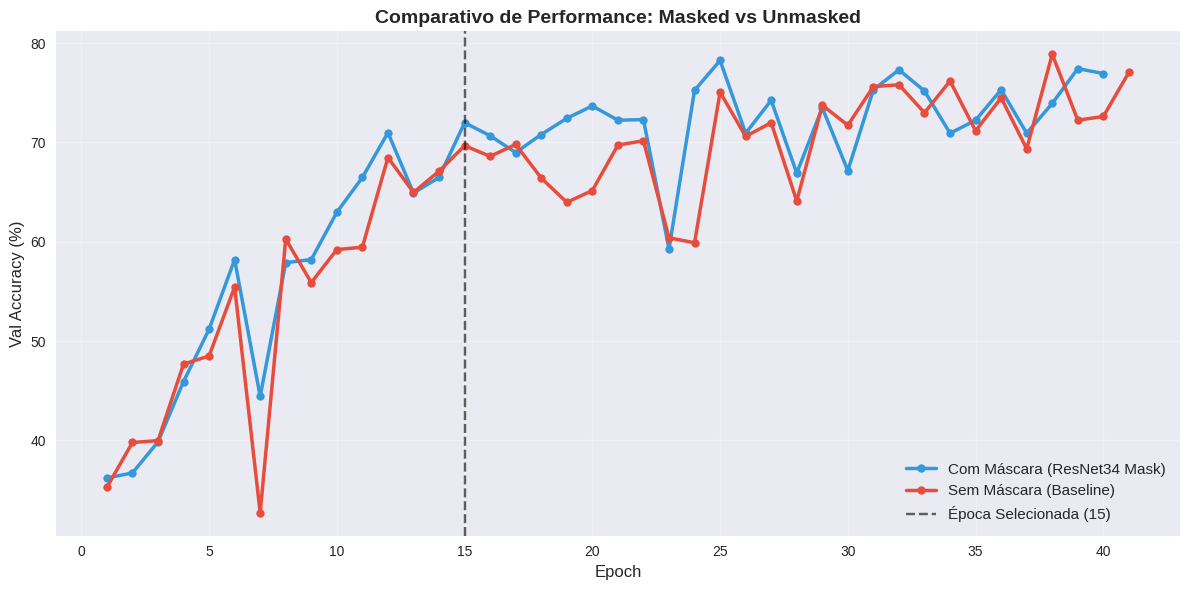

--- COMPARATIVO ÉPOCA 15 ---
Métrica         | Com Máscara  | Sem Máscara 
---------------------------------------------
val_accuracy    |       70.68% |       68.61%
val_f1_score    |       63.42% |       61.00%
val_precision   |       74.56% |       67.90%
val_recall      |       63.96% |       61.89%


In [9]:
# Configuração do Estilo
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(12, 6))

# Define qual métrica plotar (pode trocar para val_f1_score se preferir)
METRIC_NAME = "val_accuracy" 

# --- PLOTAGEM ---
# Modelo COM Máscara (Azul)
ax.plot(df_masked.epoch, df_masked[METRIC_NAME], 'o-', 
        color='#3498db', linewidth=2.5, markersize=6, label='Com Máscara (ResNet34 Mask)')

# Modelo SEM Máscara (Vermelho)
ax.plot(df_unmasked.epoch, df_unmasked[METRIC_NAME], 'o-', 
        color='#e74c3c', linewidth=2.5, markersize=6, label='Sem Máscara (Baseline)')

# --- CUSTOMIZAÇÃO ---
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel(f'{METRIC_NAME.replace("_", " ").title()} (%)', fontsize=12)
ax.set_title(f'Comparativo de Performance: Masked vs Unmasked', fontsize=14, fontweight='bold')

# Linha vertical indicando a época selecionada para inspeção
ax.axvline(x=var_global_epoch, color='black', linestyle='--', alpha=0.6, label=f'Época Selecionada ({var_global_epoch})')

ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

# --- PRINT DAS MÉTRICAS COMPARATIVAS ---
print(f"--- COMPARATIVO ÉPOCA {var_global_epoch} ---")
print(f"{'Métrica':<15} | {'Com Máscara':<12} | {'Sem Máscara':<12}")
print("-" * 45)
for m in ["val_accuracy", "val_f1_score", "val_precision", "val_recall"]:
    val_m = df_masked.at[var_global_epoch, m] if var_global_epoch in df_masked.index else 0
    val_u = df_unmasked.at[var_global_epoch, m] if var_global_epoch in df_unmasked.index else 0
    print(f"{m:<15} | {val_m:>11.2f}% | {val_u:>11.2f}%")

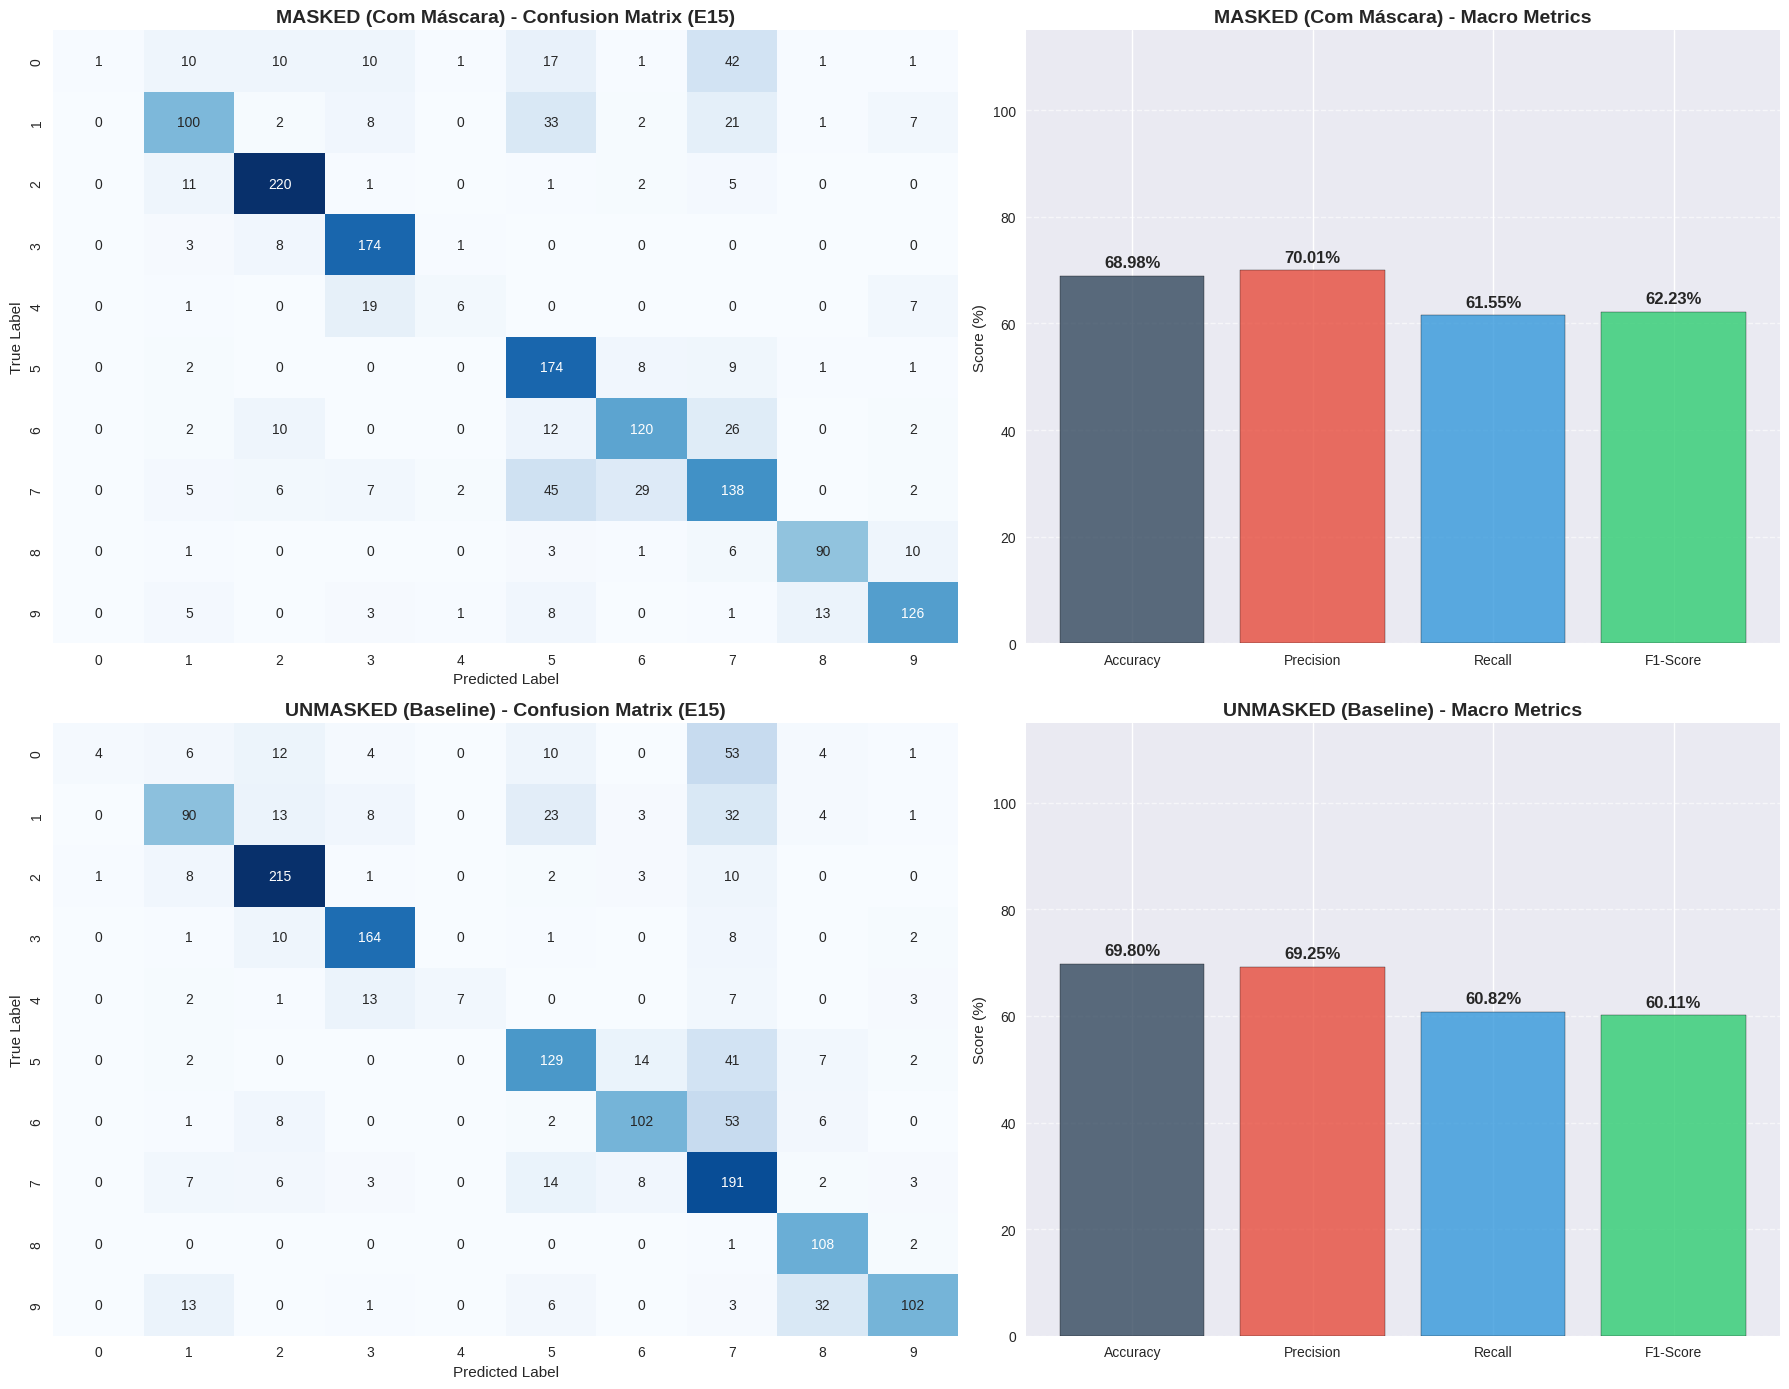


MÉTRICA (E15)        | MASKED       | UNMASKED    
--------------------------------------------------
ACCURACY             |      68.98% |      69.80%
PRECISION            |      70.01% |      69.25%
RECALL               |      61.55% |      60.82%
F1_SCORE             |      62.23% |      60.11%


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- CONFIGURAÇÕES DE ENTRADA ---
# Certifique-se de que essas variáveis existam:
# df_masked, df_unmasked, id_masked, id_unmasked, var_global_epoch

# 1. Setup da Figura (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(18, 14), gridspec_kw={'width_ratios': [1.2, 1]})

# Lista de processamento para facilitar o loop
models_to_plot = [
    {"name": "MASKED (Com Máscara)", "id": var_global_checkpoint_masked, "df": df_masked, "row": 0},
    {"name": "UNMASKED (Baseline)", "id": var_global_checkpoint_unmasked, "df": df_unmasked, "row": 1}
]

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#34495e', '#e74c3c', '#3498db', '#2ecc71']

for item in models_to_plot:
    row = item["row"]
    
    # --- A. Carregar Dados ---
    checkpoint = utils.load_checkpoint(item["id"], var_global_epoch)
    if checkpoint is None:
        print(f"⚠️ Checkpoint {item['id']} não encontrado para época {var_global_epoch}")
        continue
        
    cm = checkpoint['cm']
    df_current = item["df"]
    
    # --- B. LEFT SIDE: Confusion Matrix ---
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, 0], cbar=False)
    axes[row, 0].set_title(f'{item["name"]} - Confusion Matrix (E{var_global_epoch})', fontsize=14, fontweight='bold')
    axes[row, 0].set_xlabel('Predicted Label')
    axes[row, 0].set_ylabel('True Label')

    # --- C. RIGHT SIDE: Metrics Bar Chart ---
    # Usando a lógica de indexação que você forneceu (var_global_epoch + 1)
    try:
        m_idx = var_global_epoch + 1
        metrics_values = [
            df_current.at[m_idx, "val_accuracy"], 
            df_current.at[m_idx, "val_precision"], 
            df_current.at[m_idx, "val_recall"], 
            df_current.at[m_idx, "val_f1_score"]
        ]
    except Exception:
        metrics_values = [0, 0, 0, 0] # Fallback caso o index falhe

    bars = axes[row, 1].bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
    
    axes[row, 1].set_ylim(0, 115) 
    axes[row, 1].set_title(f'{item["name"]} - Macro Metrics', fontsize=14, fontweight='bold')
    axes[row, 1].set_ylabel('Score (%)')
    axes[row, 1].grid(axis='y', linestyle='--', alpha=0.6)

    # Labels no topo das barras
    for bar in bars:
        height = bar.get_height()
        axes[row, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# --- TABELA COMPARATIVA TEXTUAL ---
print(f"\n{'MÉTRICA (E' + str(var_global_epoch) + ')':<20} | {'MASKED':<12} | {'UNMASKED':<12}")
print("-" * 50)
for m in ["val_accuracy", "val_precision", "val_recall", "val_f1_score"]:
    v_m = df_masked.at[var_global_epoch + 1, m]
    v_u = df_unmasked.at[var_global_epoch + 1, m]
    label = m.replace("val_", "").upper()
    print(f"{label:<20} | {v_m:>10.2f}% | {v_u:>10.2f}%")